# 📦 Demand Forecasting & Inventory Optimization Engine
## Milestone 2: Forecast Model Development

---

**👥 Team Members:** Mark · Fady · Ahmed · Eman · Sama · Hadeer  
**📅 Date:** March 2026  
**🎯 Objective:** Train, evaluate, and compare multiple forecasting models.

---

### 📋 Table of Contents
1. [Setup & Data Loading](#1)
2. [Product Selection & Time Series Visualization](#2)
3. [Feature Engineering](#3)
4. [Train / Validation / Test Split](#4)
5. [Baseline Model — Naive Forecast](#5)
6. [Baseline Model — Moving Average](#6)
7. [Evaluation & Comparison](#7)
8. [Next Steps — Advanced Models](#8)

---
## 1. Setup & Data Loading <a id='1'></a>

We begin by importing all necessary libraries and loading the cleaned weekly sales dataset produced in Milestone 1.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# 1.1  Import Libraries
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import warnings
from pathlib import Path

# ── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Metrics ──────────────────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Configuration ────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
np.random.seed(42)

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = sns.color_palette('muted', 10)
print('✅ Libraries imported successfully.')

✅ Libraries imported successfully.


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# 1.2  Load Dataset
# ══════════════════════════════════════════════════════════════════════════════
DATA_PATH = Path('weekly.csv')

df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

# Rename columns for cleaner access
df.columns = [
    'Year', 'Week', 'ItemID', 'Qty',
    'ItemName', 'BrandID', 'BrandName',
    'MasterBrandID', 'MasterBrandName',
    'UOM', 'Factor',
    'Avg_Daily_Demand', 'Safety_Stock', 'ROP',
    'Avg_UnitPrice',
    'Total_Promo', 'Total_CashDiscount',
    'Total_ManualDiscount', 'Total_Taxes', 'Total_Revenue'
]

# Create proper date column from Year + ISO Week
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-W' + df['Week'].astype(str).str.zfill(2) + '-1',
    format='%G-W%V-%u'
)

print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Date range : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'   Products   : {df["ItemID"].nunique()}')
print(f'   Weeks      : {df["Week"].nunique()}')
df.head(3)

✅ Dataset loaded: 3,321 rows × 21 columns
   Date range : 2024-12-30 → 2025-06-23
   Products   : 203
   Weeks      : 26


,Year,Week,ItemID,Qty,ItemName,BrandID,BrandName,MasterBrandID,MasterBrandName,UOM,Factor,Avg_Daily_Demand,Safety_Stock,ROP,Avg_UnitPrice,Total_Promo,Total_CashDiscount,Total_ManualDiscount,Total_Taxes,Total_Revenue,Date
0,2025,1,BCH-3-08-00272,20,بوشارتي ملح,BCH-BCH01,بوشارتي,BCH,مقرمشات بوشارتي,PL,3.00,2.86,1.71,21.71,557.93,-13,0,0,"1,655.35","13,479.16",2024-12-30
1,2025,1,BCH-3-08-00273,936,بوشارتي ملح باربكيو,BCH-BCH01,بوشارتي,BCH,مقرمشات بوشارتي,PL,3.00,133.71,80.23,"1,016.23",649.54,-2254,0,0,"91,489.91","744,988.39",2024-12-30
2,2025,1,BCH-3-08-00274,1660,بوشارتي هوت باربكيو,BCH-BCH01,بوشارتي,BCH,مقرمشات بوشارتي,PL,3.00,237.14,142.29,"1,802.29",633.05,-4305,0,0,"161,971.09","1,318,905.26",2024-12-30


---
## 2. Product Selection & Time Series Visualization <a id='2'></a>

With 203 products and only 26 weeks of data, building a separate model per SKU is impractical.  
**Strategy:** Select the **top-selling product** (by total `Qty`) as a representative item and build an end-to-end forecasting pipeline.  
This pipeline can later be applied to other products.

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.1  Identify Top-Selling Products
# ══════════════════════════════════════════════════════════════════════════════
product_sales = (
    df.groupby(['ItemID', 'ItemName'])['Qty']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .head(10)
)
product_sales.columns = ['ItemID', 'ItemName', 'Total_Qty']

print('🏆 Top 10 Products by Total Weekly Sales:')
print('=' * 60)
for i, row in product_sales.iterrows():
    print(f"  {i+1}. {row['ItemName']:<35} → {row['Total_Qty']:>10,} units")

# Select the top product
TARGET_ITEM = product_sales.iloc[0]['ItemID']
TARGET_NAME = product_sales.iloc[0]['ItemName']
print(f'\n✅ Selected product: {TARGET_NAME} ({TARGET_ITEM})')

🏆 Top 10 Products by Total Weekly Sales:
  1. رايق جبنة سادة                      →    683,810 units
  2. شوكو بوم كرانشي هوت                 →    344,298 units
  3. شوكو بوم كاتشب سبايسي               →    315,787 units
  4. فرفشة هوت كوول                      →    258,480 units
  5. فرفشة ملح سادة                      →    254,150 units
  6. بوشارتي هوت باربكيو                 →    210,231 units
  7. بوشارتي هوت باربكيو نيو             →    154,887 units
  8. رايق شوكولاتة كرز                   →    132,500 units
  9. بوشارتي ملح باربكيو                 →    130,899 units
  10. رايق بوب كورن سادة                  →    130,328 units

✅ Selected product: رايق جبنة سادة (FRF-2-02-00070)


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.2  Filter Data for Selected Product
# ══════════════════════════════════════════════════════════════════════════════
product_df = (
    df[df['ItemID'] == TARGET_ITEM]
    .sort_values('Date')
    .reset_index(drop=True)
    .copy()
)

print(f'📊 Product time series: {len(product_df)} weeks')
print(f'   Qty range: {product_df["Qty"].min():,} → {product_df["Qty"].max():,}')
print(f'   Qty mean : {product_df["Qty"].mean():,.1f}')
print(f'   Qty std  : {product_df["Qty"].std():,.1f}')
product_df[['Date', 'Week', 'Qty', 'Avg_UnitPrice', 'Total_Promo', 'Total_Revenue']].head(10)

📊 Product time series: 26 weeks
   Qty range: 441 → 43,614
   Qty mean : 26,300.4
   Qty std  : 9,690.1


,Date,Week,Qty,Avg_UnitPrice,Total_Promo,Total_Revenue
0,2024-12-30,1,17873,147.66,-11775,"2,926,170.69"
1,2025-01-06,2,23596,144.46,-18374,"3,741,032.18"
2,2025-01-13,3,25120,139.94,-17551,"4,082,525.12"
3,2025-01-20,4,26519,140.11,-17169,"4,269,972.19"
4,2025-01-27,5,19646,145.05,-15483,"3,178,237.67"
5,2025-02-03,6,29719,144.84,-18047,"4,613,409.41"
6,2025-02-10,7,40636,145.61,-21116,"6,538,093.35"
7,2025-02-17,8,34679,143.40,-24362,"5,605,505.72"
8,2025-02-24,9,23136,136.44,-15033,"3,684,470.19"
9,2025-03-03,10,37064,146.01,-10244,"6,058,030.47"


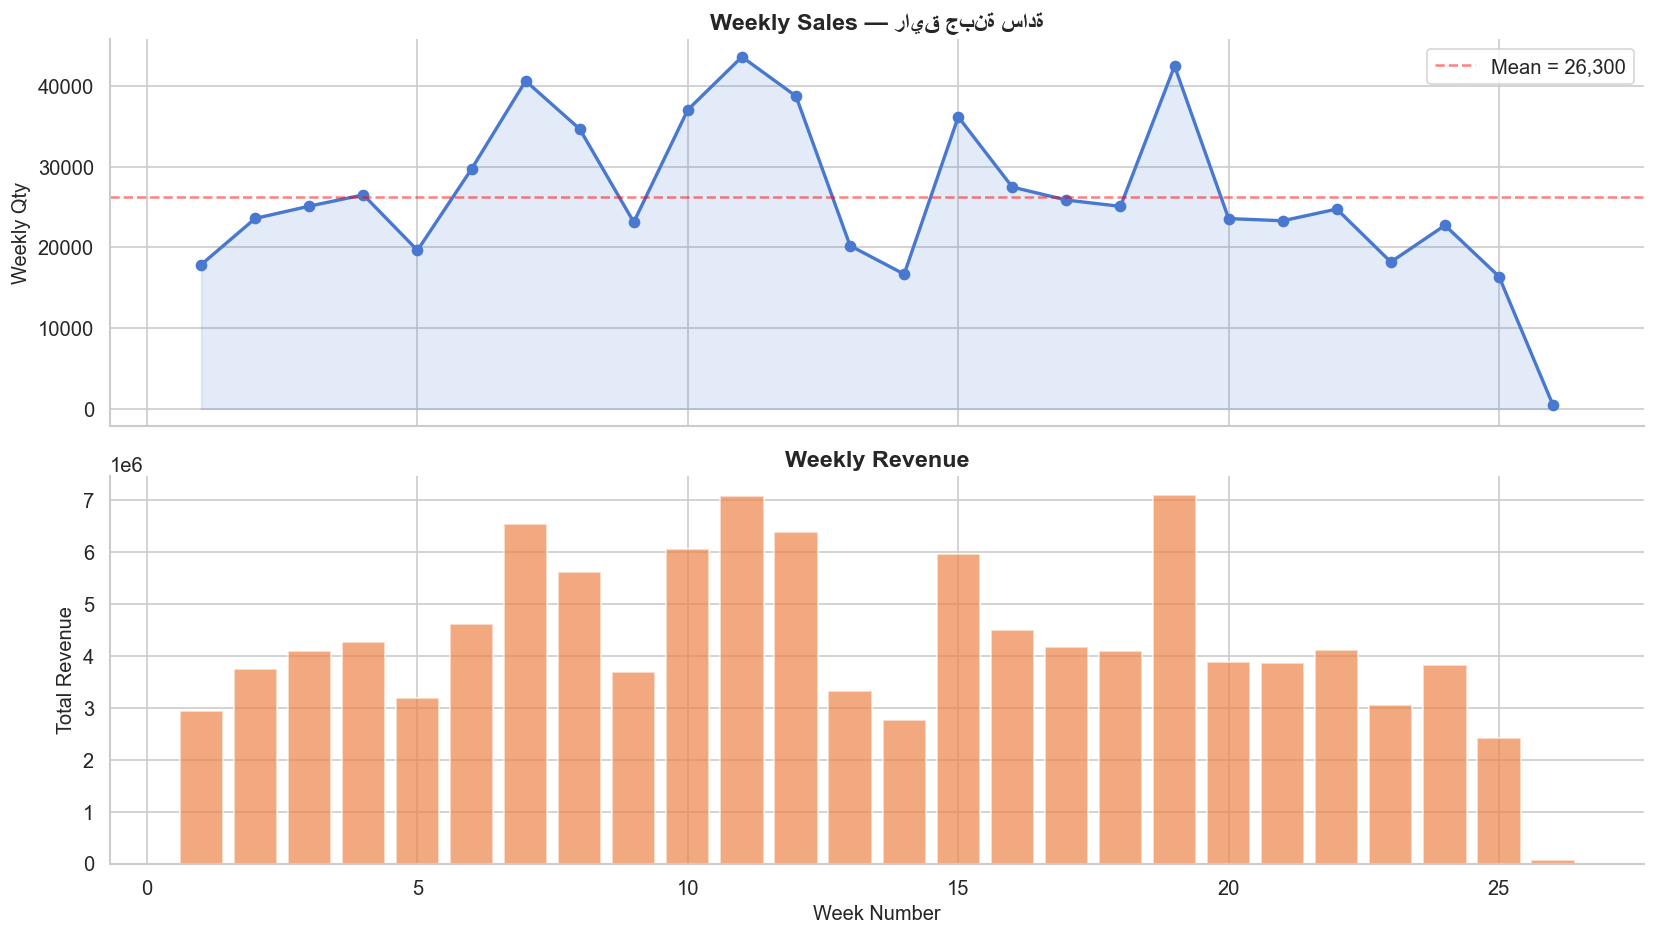

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.3  Visualize the Time Series
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot 1: Qty over time
axes[0].plot(product_df['Week'], product_df['Qty'], 'o-', color=COLORS[0], linewidth=2, markersize=6)
axes[0].fill_between(product_df['Week'], product_df['Qty'], alpha=0.15, color=COLORS[0])
axes[0].set_ylabel('Weekly Qty', fontsize=12)
axes[0].set_title(f'Weekly Sales — {TARGET_NAME}', fontsize=14, fontweight='bold')
axes[0].axhline(y=product_df['Qty'].mean(), color='red', linestyle='--', alpha=0.5, label=f'Mean = {product_df["Qty"].mean():,.0f}')
axes[0].legend()

# Plot 2: Total Revenue over time
axes[1].bar(product_df['Week'], product_df['Total_Revenue'], color=COLORS[1], alpha=0.7)
axes[1].set_ylabel('Total Revenue', fontsize=12)
axes[1].set_xlabel('Week Number', fontsize=12)
axes[1].set_title('Weekly Revenue', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3. Feature Engineering <a id='3'></a>

Time-series models like XGBoost need **lag features** and **rolling statistics** to learn from past patterns.  
We create:

| Feature | Description | Why it Helps |
|---------|-------------|-------------|
| `lag_1` | Qty from previous week | Captures short-term momentum |
| `lag_2` | Qty from 2 weeks ago | Medium-term trend |
| `lag_4` | Qty from 4 weeks ago | Monthly cycle |
| `rolling_mean_4` | Average of last 4 weeks | Smooths noise, captures trend |
| `rolling_std_4` | Std dev of last 4 weeks | Captures volatility |
| `Avg_UnitPrice` | Average unit price | Price sensitivity |
| `Total_Promo` | Total promotions | Promotional impact |

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# 3.1  Create Lag Features
# ══════════════════════════════════════════════════════════════════════════════
product_df['lag_1'] = product_df['Qty'].shift(1)
product_df['lag_2'] = product_df['Qty'].shift(2)
product_df['lag_4'] = product_df['Qty'].shift(4)

# ══════════════════════════════════════════════════════════════════════════════
# 3.2  Create Rolling Statistics
# ══════════════════════════════════════════════════════════════════════════════
product_df['rolling_mean_4'] = product_df['Qty'].shift(1).rolling(window=4).mean()
product_df['rolling_std_4']  = product_df['Qty'].shift(1).rolling(window=4).std()

# ══════════════════════════════════════════════════════════════════════════════
# 3.3  Week-based Features
# ══════════════════════════════════════════════════════════════════════════════
product_df['month'] = product_df['Date'].dt.month

print('✅ Features created successfully.')
print(f'   Total columns: {product_df.shape[1]}')
print(f'   NaN rows (due to lag/rolling): {product_df["lag_4"].isna().sum()} from lag_4, '
      f'{product_df["rolling_mean_4"].isna().sum()} from rolling_mean_4')
print()
product_df[['Date', 'Week', 'Qty', 'lag_1', 'lag_2', 'lag_4', 'rolling_mean_4', 'rolling_std_4']].head(10)

✅ Features created successfully.
   Total columns: 27
   NaN rows (due to lag/rolling): 4 from lag_4, 4 from rolling_mean_4



,Date,Week,Qty,lag_1,lag_2,lag_4,rolling_mean_4,rolling_std_4
0,2024-12-30,1,17873,NaN,NaN,NaN,NaN,NaN
1,2025-01-06,2,23596,"17,873.00",NaN,NaN,NaN,NaN
2,2025-01-13,3,25120,"23,596.00","17,873.00",NaN,NaN,NaN
3,2025-01-20,4,26519,"25,120.00","23,596.00",NaN,NaN,NaN
4,2025-01-27,5,19646,"26,519.00","25,120.00","17,873.00","23,277.00","3,795.27"
5,2025-02-03,6,29719,"19,646.00","26,519.00","23,596.00","23,720.25","2,966.89"
6,2025-02-10,7,40636,"29,719.00","19,646.00","25,120.00","25,251.00","4,203.33"
7,2025-02-17,8,34679,"40,636.00","29,719.00","26,519.00","29,130.00","8,746.40"
8,2025-02-24,9,23136,"34,679.00","40,636.00","19,646.00","31,170.00","8,884.94"
9,2025-03-03,10,37064,"23,136.00","34,679.00","29,719.00","32,042.50","7,427.96"


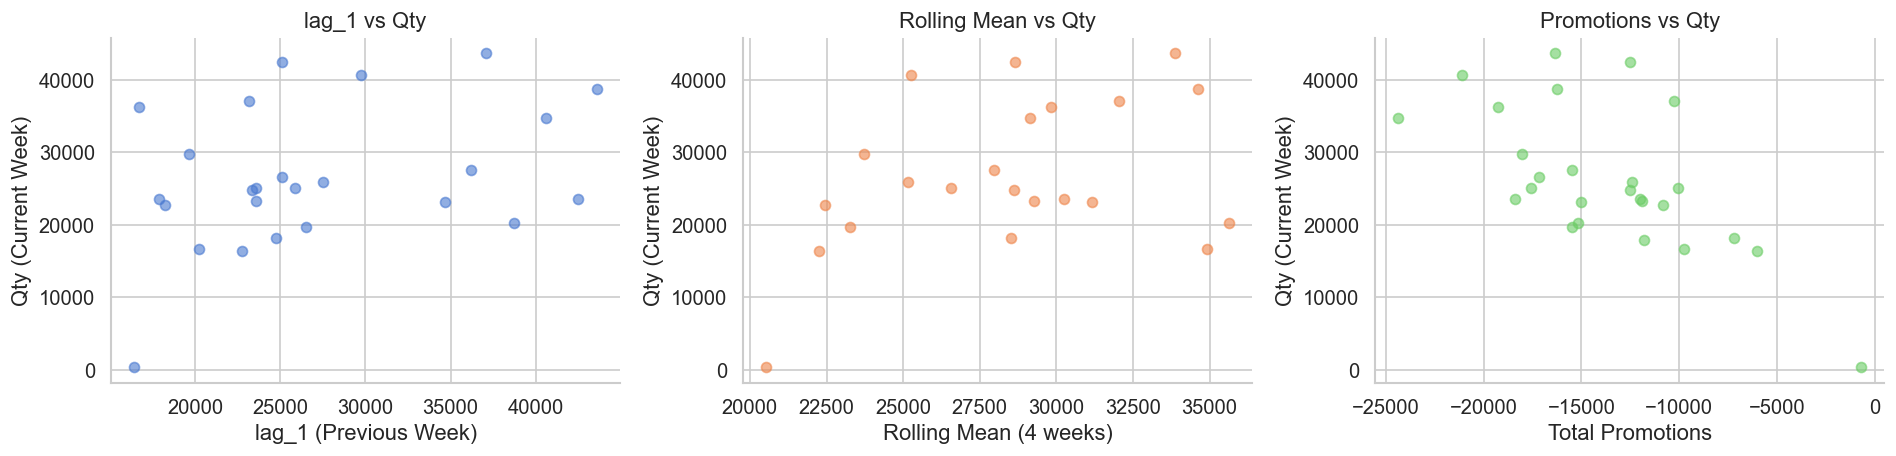

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# 3.4  Visualize Features vs Target
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Lag 1 vs Qty
axes[0].scatter(product_df['lag_1'], product_df['Qty'], alpha=0.6, color=COLORS[0])
axes[0].set_xlabel('lag_1 (Previous Week)')
axes[0].set_ylabel('Qty (Current Week)')
axes[0].set_title('lag_1 vs Qty')

# Rolling Mean vs Qty
axes[1].scatter(product_df['rolling_mean_4'], product_df['Qty'], alpha=0.6, color=COLORS[1])
axes[1].set_xlabel('Rolling Mean (4 weeks)')
axes[1].set_ylabel('Qty (Current Week)')
axes[1].set_title('Rolling Mean vs Qty')

# Total Promo vs Qty
axes[2].scatter(product_df['Total_Promo'], product_df['Qty'], alpha=0.6, color=COLORS[2])
axes[2].set_xlabel('Total Promotions')
axes[2].set_ylabel('Qty (Current Week)')
axes[2].set_title('Promotions vs Qty')

plt.tight_layout()
plt.show()

---
## 4. Train / Validation / Test Split (Time-Based) <a id='4'></a>

**⚠️ Critical:** For time-series data, we **must** split chronologically.  
Random splitting would cause **data leakage** — the model would see future data during training.

```
Week 1 ─────── Week 18 ──── Week 22 ──── Week 26
│     TRAIN (70%)    │  VAL (15%)  │ TEST (15%) │
└────────────────────┴─────────────┴────────────┘
```

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.1  Time-Based Split
# ══════════════════════════════════════════════════════════════════════════════
n = len(product_df)
train_end = int(n * 0.70)   # 70% for training
val_end   = int(n * 0.85)   # 15% for validation

train_df = product_df.iloc[:train_end].copy()
val_df   = product_df.iloc[train_end:val_end].copy()
test_df  = product_df.iloc[val_end:].copy()

print('📊 Data Split Summary:')
print('=' * 55)
print(f'  Total    : {n:>3} weeks')
print(f'  Train    : {len(train_df):>3} weeks  (Weeks {train_df["Week"].iloc[0]:>2} → {train_df["Week"].iloc[-1]:>2})  {len(train_df)/n*100:.0f}%')
print(f'  Validation: {len(val_df):>3} weeks  (Weeks {val_df["Week"].iloc[0]:>2} → {val_df["Week"].iloc[-1]:>2})  {len(val_df)/n*100:.0f}%')
print(f'  Test     : {len(test_df):>3} weeks  (Weeks {test_df["Week"].iloc[0]:>2} → {test_df["Week"].iloc[-1]:>2})  {len(test_df)/n*100:.0f}%')

📊 Data Split Summary:
  Total    :  26 weeks
  Train    :  18 weeks  (Weeks  1 → 18)  69%
  Validation:   4 weeks  (Weeks 19 → 22)  15%
  Test     :   4 weeks  (Weeks 23 → 26)  15%


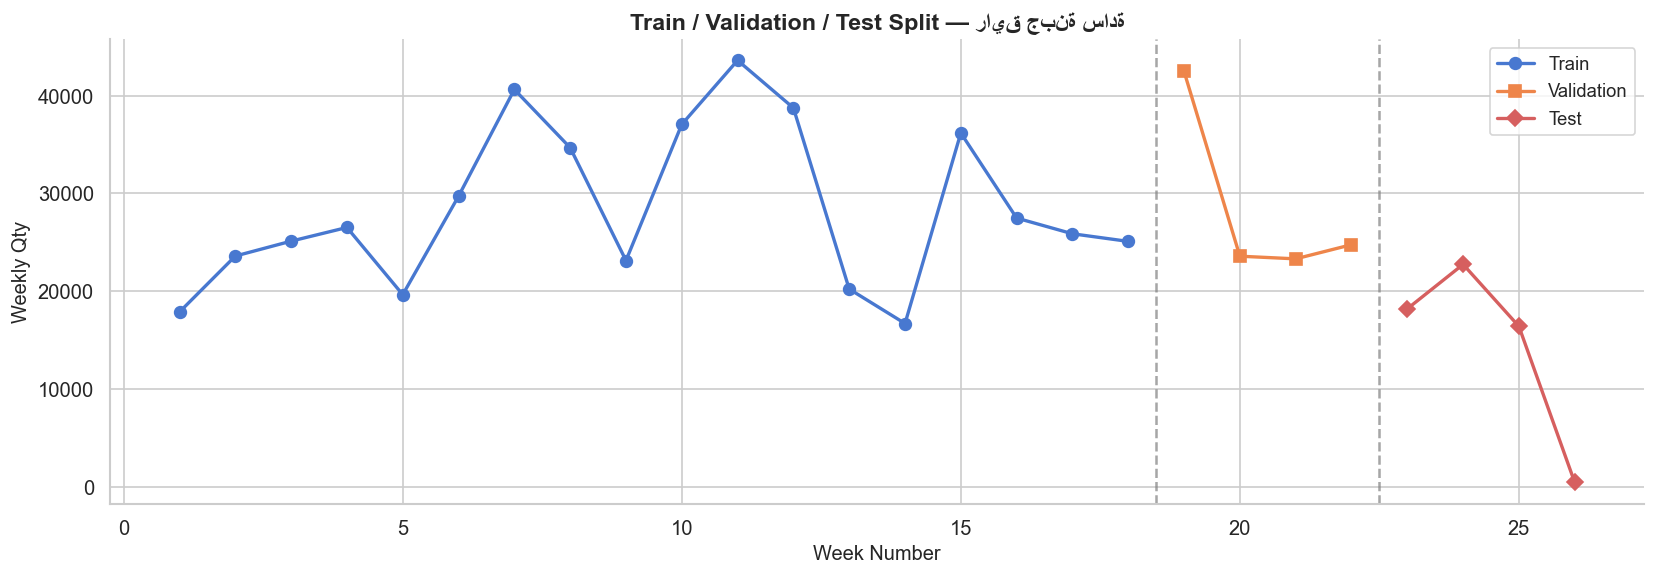

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.2  Visualize the Split
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train_df['Week'], train_df['Qty'], 'o-', color=COLORS[0], linewidth=2, label='Train', markersize=7)
ax.plot(val_df['Week'], val_df['Qty'], 's-', color=COLORS[1], linewidth=2, label='Validation', markersize=7)
ax.plot(test_df['Week'], test_df['Qty'], 'D-', color=COLORS[3], linewidth=2, label='Test', markersize=7)

# Vertical dividers
ax.axvline(x=val_df['Week'].iloc[0] - 0.5, color='gray', linestyle='--', alpha=0.7)
ax.axvline(x=test_df['Week'].iloc[0] - 0.5, color='gray', linestyle='--', alpha=0.7)

ax.set_xlabel('Week Number', fontsize=12)
ax.set_ylabel('Weekly Qty', fontsize=12)
ax.set_title(f'Train / Validation / Test Split — {TARGET_NAME}', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## 5. Baseline Model — Naive Forecast <a id='5'></a>

**The Naive Forecast** predicts that next week's demand = this week's demand.

$$\hat{y}_{t+1} = y_t$$

This is the simplest possible model but serves as a **critical benchmark**.  
Any more complex model must beat the baseline to justify its complexity.

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# 5.1  Naive Forecast on Validation Set
# ══════════════════════════════════════════════════════════════════════════════

# Naive: predict last known value
# For the validation set, each prediction = previous week's actual value
val_df = val_df.copy()
val_df['Naive_Pred'] = val_df['Qty'].shift(1)

# First row has no previous in val, use last train value
val_df.iloc[0, val_df.columns.get_loc('Naive_Pred')] = train_df['Qty'].iloc[-1]

print('📋 Naive Forecast — Validation Set:')
print(val_df[['Week', 'Qty', 'Naive_Pred']].to_string(index=False))

📋 Naive Forecast — Validation Set:
 Week   Qty  Naive_Pred
   19 42480   25,095.00
   20 23580   42,480.00
   21 23309   23,580.00
   22 24757   23,309.00


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# 5.2  Naive Forecast on Test Set
# ══════════════════════════════════════════════════════════════════════════════
test_df = test_df.copy()
test_df['Naive_Pred'] = test_df['Qty'].shift(1)

# First row: use last validation value
test_df.iloc[0, test_df.columns.get_loc('Naive_Pred')] = val_df['Qty'].iloc[-1]

print('📋 Naive Forecast — Test Set:')
print(test_df[['Week', 'Qty', 'Naive_Pred']].to_string(index=False))

📋 Naive Forecast — Test Set:
 Week   Qty  Naive_Pred
   23 18200   24,757.00
   24 22745   18,200.00
   25 16400   22,745.00
   26   441   16,400.00


---
## 6. Baseline Model — Moving Average <a id='6'></a>

**Moving Average** smooths out noise by averaging the last *N* periods.

$$\hat{y}_{t+1} = \frac{1}{N} \sum_{i=1}^{N} y_{t-i+1}$$

We use **N = 4** (a 4-week moving average) to capture approximately monthly patterns.

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# 6.1  Moving Average on Validation Set
# ══════════════════════════════════════════════════════════════════════════════
MA_WINDOW = 4

# Build full history from train + val for rolling calculation
full_series = pd.concat([train_df[['Week', 'Qty']], val_df[['Week', 'Qty']]], ignore_index=True)

# Calculate MA for each validation week using only past data
ma_preds_val = []
for i in range(len(val_df)):
    # Take the last MA_WINDOW values before this point
    history_end = len(train_df) + i
    history = full_series['Qty'].iloc[max(0, history_end - MA_WINDOW):history_end]
    ma_preds_val.append(history.mean())

val_df['MA_Pred'] = ma_preds_val

print(f'📋 Moving Average (window={MA_WINDOW}) — Validation Set:')
print(val_df[['Week', 'Qty', 'Naive_Pred', 'MA_Pred']].to_string(index=False))

📋 Moving Average (window=4) — Validation Set:
 Week   Qty  Naive_Pred   MA_Pred
   19 42480   25,095.00 28,658.50
   20 23580   42,480.00 30,232.75
   21 23309   23,580.00 29,257.25
   22 24757   23,309.00 28,616.00


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# 6.2  Moving Average on Test Set
# ══════════════════════════════════════════════════════════════════════════════
full_series_test = pd.concat([train_df[['Week', 'Qty']], val_df[['Week', 'Qty']], test_df[['Week', 'Qty']]], ignore_index=True)

ma_preds_test = []
for i in range(len(test_df)):
    history_end = len(train_df) + len(val_df) + i
    history = full_series_test['Qty'].iloc[max(0, history_end - MA_WINDOW):history_end]
    ma_preds_test.append(history.mean())

test_df['MA_Pred'] = ma_preds_test

print(f'📋 Moving Average (window={MA_WINDOW}) — Test Set:')
print(test_df[['Week', 'Qty', 'Naive_Pred', 'MA_Pred']].to_string(index=False))

📋 Moving Average (window=4) — Test Set:
 Week   Qty  Naive_Pred   MA_Pred
   23 18200   24,757.00 28,531.50
   24 22745   18,200.00 22,461.50
   25 16400   22,745.00 22,252.75
   26   441   16,400.00 20,525.50


---
## 7. Evaluation & Comparison <a id='7'></a>

We evaluate both baseline models using four standard metrics:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MAE** | Mean Absolute Error | Average absolute error in units |
| **RMSE** | Root Mean Squared Error | Penalizes large errors more |
| **MAPE** | Mean Abs Percentage Error | Error as percentage |
| **R²** | Coefficient of Determination | 1.0 = perfect, 0 = mean baseline |

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# 7.1  Evaluation Helper Function
# ══════════════════════════════════════════════════════════════════════════════
def evaluate_model(y_true, y_pred, model_name='Model'):
    """Calculate and return evaluation metrics."""
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true = np.array(y_true)[mask]
    y_pred = np.array(y_pred)[mask]
    
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE: avoid division by zero
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    r2   = r2_score(y_true, y_pred)
    
    return {
        'Model': model_name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE (%)': round(mape, 2),
        'R²': round(r2, 4)
    }

print('✅ Evaluation function ready.')

✅ Evaluation function ready.


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# 7.2  Evaluate on Validation Set
# ══════════════════════════════════════════════════════════════════════════════
results_val = []
results_val.append(evaluate_model(val_df['Qty'], val_df['Naive_Pred'], 'Naive Forecast'))
results_val.append(evaluate_model(val_df['Qty'], val_df['MA_Pred'], f'Moving Average ({MA_WINDOW}w)'))

results_val_df = pd.DataFrame(results_val)
print('📊 Validation Set Results:')
print('=' * 60)
print(results_val_df.to_string(index=False))

📊 Validation Set Results:
              Model      MAE      RMSE  MAPE (%)    R²
     Naive Forecast 9,501.00 12,860.97     32.02 -1.54
Moving Average (4w) 7,570.38  8,449.36     25.46 -0.10


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# 7.3  Evaluate on Test Set
# ══════════════════════════════════════════════════════════════════════════════
results_test = []
results_test.append(evaluate_model(test_df['Qty'], test_df['Naive_Pred'], 'Naive Forecast'))
results_test.append(evaluate_model(test_df['Qty'], test_df['MA_Pred'], f'Moving Average ({MA_WINDOW}w)'))

results_test_df = pd.DataFrame(results_test)
print('📊 Test Set Results:')
print('=' * 60)
print(results_test_df.to_string(index=False))

📊 Test Set Results:
              Model      MAE      RMSE  MAPE (%)    R²
     Naive Forecast 8,351.50  9,468.37    928.38 -0.27
Moving Average (4w) 9,138.06 11,666.86  1,162.00 -0.92


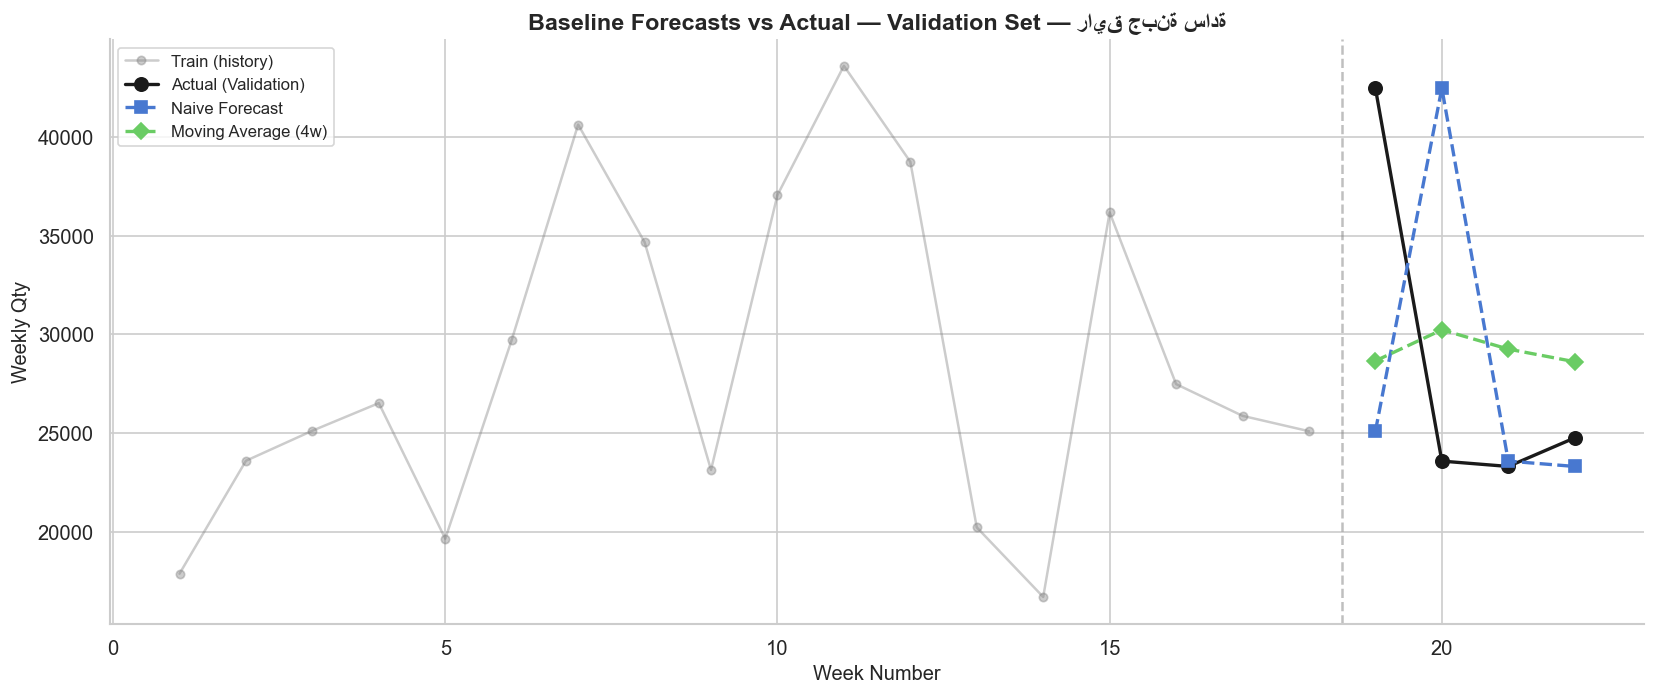

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# 7.4  Visualization — Actual vs Predicted (Validation)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))

# Training data
ax.plot(train_df['Week'], train_df['Qty'], 'o-', color='gray', alpha=0.4,
        linewidth=1.5, markersize=5, label='Train (history)')

# Actual validation
ax.plot(val_df['Week'], val_df['Qty'], 'ko-', linewidth=2, markersize=8, label='Actual (Validation)')

# Naive prediction
ax.plot(val_df['Week'], val_df['Naive_Pred'], 's--', color=COLORS[0],
        linewidth=2, markersize=7, label='Naive Forecast')

# MA prediction
ax.plot(val_df['Week'], val_df['MA_Pred'], 'D--', color=COLORS[2],
        linewidth=2, markersize=7, label=f'Moving Average ({MA_WINDOW}w)')

ax.axvline(x=val_df['Week'].iloc[0] - 0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Week Number', fontsize=12)
ax.set_ylabel('Weekly Qty', fontsize=12)
ax.set_title(f'Baseline Forecasts vs Actual — Validation Set — {TARGET_NAME}',
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

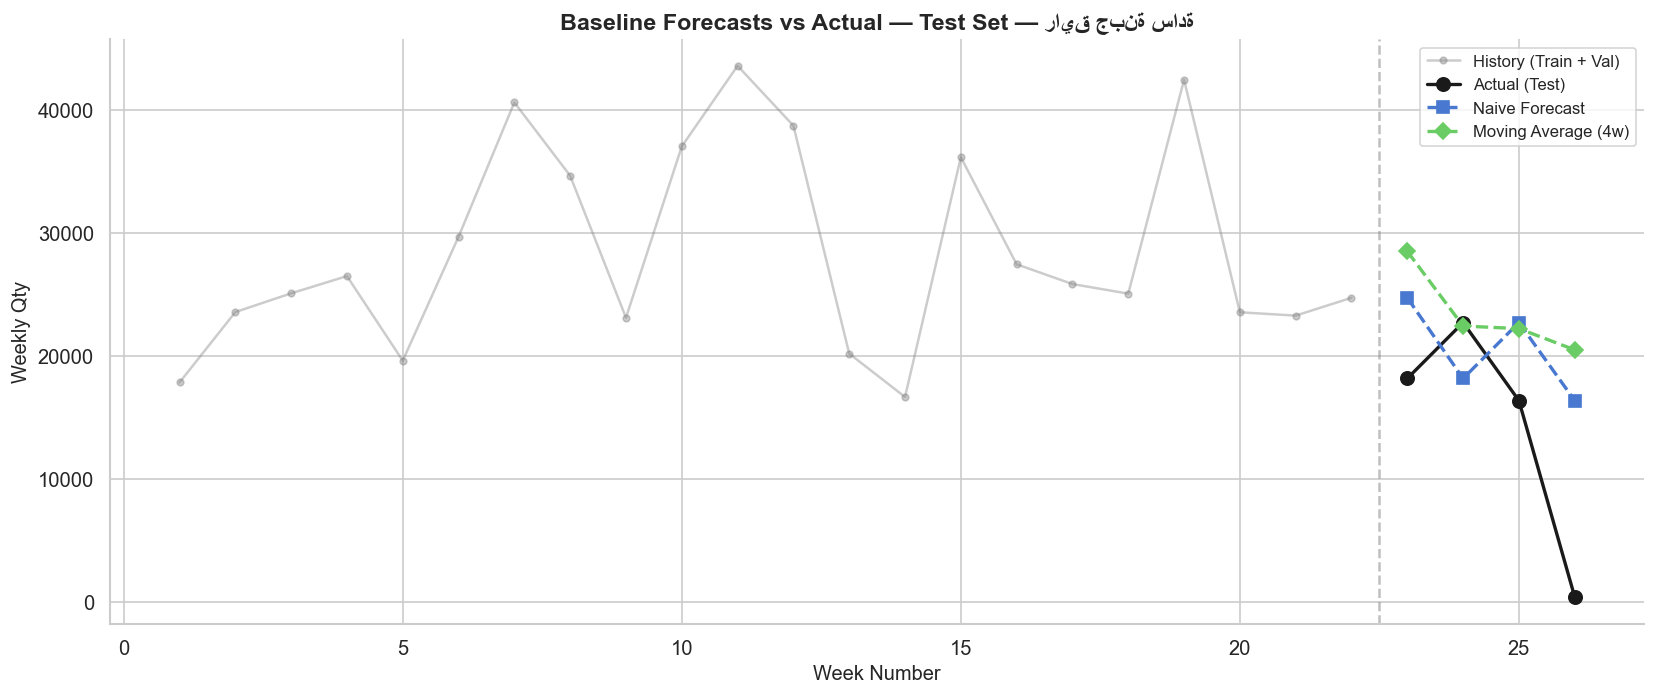

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# 7.5  Visualization — Actual vs Predicted (Test)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))

# Full history
history_weeks = list(train_df['Week']) + list(val_df['Week'])
history_qty   = list(train_df['Qty']) + list(val_df['Qty'])
ax.plot(history_weeks, history_qty, 'o-', color='gray', alpha=0.4,
        linewidth=1.5, markersize=4, label='History (Train + Val)')

# Actual test
ax.plot(test_df['Week'], test_df['Qty'], 'ko-', linewidth=2, markersize=8, label='Actual (Test)')

# Naive
ax.plot(test_df['Week'], test_df['Naive_Pred'], 's--', color=COLORS[0],
        linewidth=2, markersize=7, label='Naive Forecast')

# MA
ax.plot(test_df['Week'], test_df['MA_Pred'], 'D--', color=COLORS[2],
        linewidth=2, markersize=7, label=f'Moving Average ({MA_WINDOW}w)')

ax.axvline(x=test_df['Week'].iloc[0] - 0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Week Number', fontsize=12)
ax.set_ylabel('Weekly Qty', fontsize=12)
ax.set_title(f'Baseline Forecasts vs Actual — Test Set — {TARGET_NAME}',
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# 7.6  Combined Results Table
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '=' * 70)
print('📊 BASELINE MODEL COMPARISON — SUMMARY')
print('=' * 70)

print('\n▶ Validation Set:')
print(results_val_df.to_string(index=False))

print('\n▶ Test Set:')
print(results_test_df.to_string(index=False))

# Determine best baseline
best_val = results_val_df.loc[results_val_df['MAE'].idxmin(), 'Model']
best_test = results_test_df.loc[results_test_df['MAE'].idxmin(), 'Model']
print(f'\n🏆 Best Baseline (Validation): {best_val}')
print(f'🏆 Best Baseline (Test)      : {best_test}')
print('=' * 70)


📊 BASELINE MODEL COMPARISON — SUMMARY

▶ Validation Set:
              Model      MAE      RMSE  MAPE (%)    R²
     Naive Forecast 9,501.00 12,860.97     32.02 -1.54
Moving Average (4w) 7,570.38  8,449.36     25.46 -0.10

▶ Test Set:
              Model      MAE      RMSE  MAPE (%)    R²
     Naive Forecast 8,351.50  9,468.37    928.38 -0.27
Moving Average (4w) 9,138.06 11,666.86  1,162.00 -0.92

🏆 Best Baseline (Validation): Moving Average (4w)
🏆 Best Baseline (Test)      : Naive Forecast


---
## 8. Next Steps — Advanced Models <a id='8'></a>

The baseline models establish a **performance floor**. Any advanced model must beat these metrics.

### Coming Next:

| Model | Type | Expected Improvement |
|-------|------|---------------------|
| **SARIMA** | Statistical time-series | Captures seasonality and trend |
| **Prophet** | Facebook's time-series | Handles holidays and changepoints |
| **XGBoost** | Gradient Boosting (ML) | Leverages lag features + external data (price, promo) |

### Key Observations:
- The **lag features** (lag_1, rolling_mean_4) show correlation with Qty → XGBoost will benefit
- The data has **26 weeks only** → SARIMA may struggle with limited seasonality data
- **Promotions** appear to influence sales → XGBoost can leverage this

---
💡 *End of Baseline Section — Milestone 2 (Part 1)*